# 01 — Attention Mechanism Exploration

This notebook visualises and compares the attention mechanisms implemented in the
Efficient Transformer Toolkit: **Vanilla (Multi-Head)**, **FlashAttention**,
**ALiBi**, and **Grouped-Query Attention (GQA)**.

We will:
1. Instantiate small transformer models with each attention variant.
2. Pass random input sequences and extract attention weight matrices.
3. Plot attention heatmaps using `src/visualization/attention_map.py`.
4. Discuss the mathematical differences between each mechanism.

## Setup

In [1]:
import sys
from pathlib import Path

# Ensure the project root is on the Python path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.models.transformer import Transformer, TransformerConfig
from src.visualization.attention_map import (
    AttentionExtractor,
    compute_attention_manually,
    plot_attention_heatmap,
    plot_attention_grid,
    plot_layer_comparison,
    plot_head_importance,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.13.0+cu126


## 1 — Model Configuration

We use a small model (6 layers, 8 heads, d_model=512) to keep things fast.
The only thing that changes between variants is `attn_type`.

In [2]:
BASE_CFG=dict(
    vocab_size=10_000,
    d_model=512,
    n_heads=8,
    n_layers=6,
    max_seq_len=512,
    causal=True,
    dropout=0.0,
    use_bias=False,
    tie_embeddings=True,
    layer_norm_type="pre",
    ffn_activation="swiglu",
)

ATTENTION_VARIANTS = {
    "Multi-Head (Vanilla)": dict(attn_type="flashv2", use_flash=False),
    "FlashAttention v2":    dict(attn_type="flashv2", use_flash=True),
    "ALiBi":                dict(attn_type="alibi",   use_flash=False, pos_encoding="sinusoidal"),
    "GQA (4 KV heads)":     dict(attn_type="gqa",     use_flash=False, n_kv_heads=4),
}

print(f"Variants to build: {list(ATTENTION_VARIANTS.keys())}")

Variants to build: ['Multi-Head (Vanilla)', 'FlashAttention v2', 'ALiBi', 'GQA (4 KV heads)']


## 2 — Instantiate Models

In [3]:
models = {}
for name, overrides in ATTENTION_VARIANTS.items():
    cfg_dict = {**BASE_CFG, **overrides}
    try:
        config = TransformerConfig(**cfg_dict)
        model = Transformer(config, use_encoder=False, use_decoder=True)
        model = model.to(DEVICE).eval()
        n_params = sum(p.numel() for p in model.parameters())
        models[name] = model
        print(f"  {name:30s}  params={n_params:>12,}")
    except Exception as e:
        print(f"  {name:30s}  SKIPPED ({e})")

print(f"\nSuccessfully built {len(models)} models.")

  Multi-Head (Vanilla)            params=  36,596,736
  FlashAttention v2               params=  36,596,736
  ALiBi                           params=  36,596,736


C:\Users\aryan\Desktop\Efficient-Transformer-Toolkit\src\models\transformer.py:217: UserWarning: pos_encoding='rope' requires RotaryPEMultiHeadAttention; ignoring attn_type='gqa' (flashv2 is the default, so this only fires when attn_type was explicitly set).
  self.self_attn = get_attention(config)
C:\Users\aryan\Desktop\Efficient-Transformer-Toolkit\src\models\transformer.py:218: UserWarning: pos_encoding='rope' requires RotaryPEMultiHeadAttention; ignoring attn_type='gqa' (flashv2 is the default, so this only fires when attn_type was explicitly set).
  self.cross_attn = get_attention(config)


  GQA (4 KV heads)                params=  36,596,736

Successfully built 4 models.


## 3 — Generate Attention Maps

We create a short synthetic token sequence and pass it through each model.
The `AttentionExtractor` registers forward hooks on attention modules and
captures the raw attention weight matrices.

In [4]:
SEQ_LEN = 32
tokens = [f"tok{i}" for i in range(SEQ_LEN)]
input_ids = torch.randint(0, BASE_CFG["vocab_size"], (1, SEQ_LEN), device=DEVICE)

print(f"Input shape: {input_ids.shape}")
print(f"Sample tokens: {tokens[:8]} ...")

Input shape: torch.Size([1, 32])
Sample tokens: ['tok0', 'tok1', 'tok2', 'tok3', 'tok4', 'tok5', 'tok6', 'tok7'] ...


In [5]:
attention_weights = {}  # name -> dict[layer_idx -> tensor]

for name, model in models.items():
    print(f"\nExtracting attention from: {name}")
    extractor = AttentionExtractor(model)
    try:
        attn_dict = extractor.extract(input_ids, layer_idx=None, head_idx=0)
        attention_weights[name] = attn_dict
        n_layers = len(attn_dict)
        sample_key = list(attn_dict.keys())[0]
        sample_shape = attn_dict[sample_key].shape
        print(f"  Captured {n_layers} layers, first layer shape: {sample_shape}")
    except Exception as e:
        print(f"  Hook extraction failed: {e}")
        # Fallback: manual computation
        try:
            with torch.no_grad():
                _ = model(input_ids)
            attn_dict = {}
            attn_dict[0] = compute_attention_manually(model, input_ids, layer_idx=0, head_idx=0)
            attention_weights[name] = attn_dict
            print(f"  Manual extraction succeeded, shape: {attn_dict[0].shape}")
        except Exception as e2:
            print(f"  Manual extraction also failed: {e2}")
    extractor.remove_hooks()


Extracting attention from: Multi-Head (Vanilla)
  Hook extraction failed: No attention weights were captured. This repo's attention modules return a plain tensor from forward(), not (output, attn_weights), so the forward-hook approach used here can't intercept weights. Use compute_attention_manually() instead.
  Manual extraction succeeded, shape: torch.Size([32, 32])

Extracting attention from: FlashAttention v2
  Hook extraction failed: No attention weights were captured. This repo's attention modules return a plain tensor from forward(), not (output, attn_weights), so the forward-hook approach used here can't intercept weights. Use compute_attention_manually() instead.
  Manual extraction succeeded, shape: torch.Size([32, 32])

Extracting attention from: ALiBi
  Hook extraction failed: No attention weights were captured. This repo's attention modules return a plain tensor from forward(), not (output, attn_weights), so the forward-hook approach used here can't intercept weights. Use

### 3.1 — Single-Layer Heatmaps

Compare the attention pattern of layer 0 across all variants.

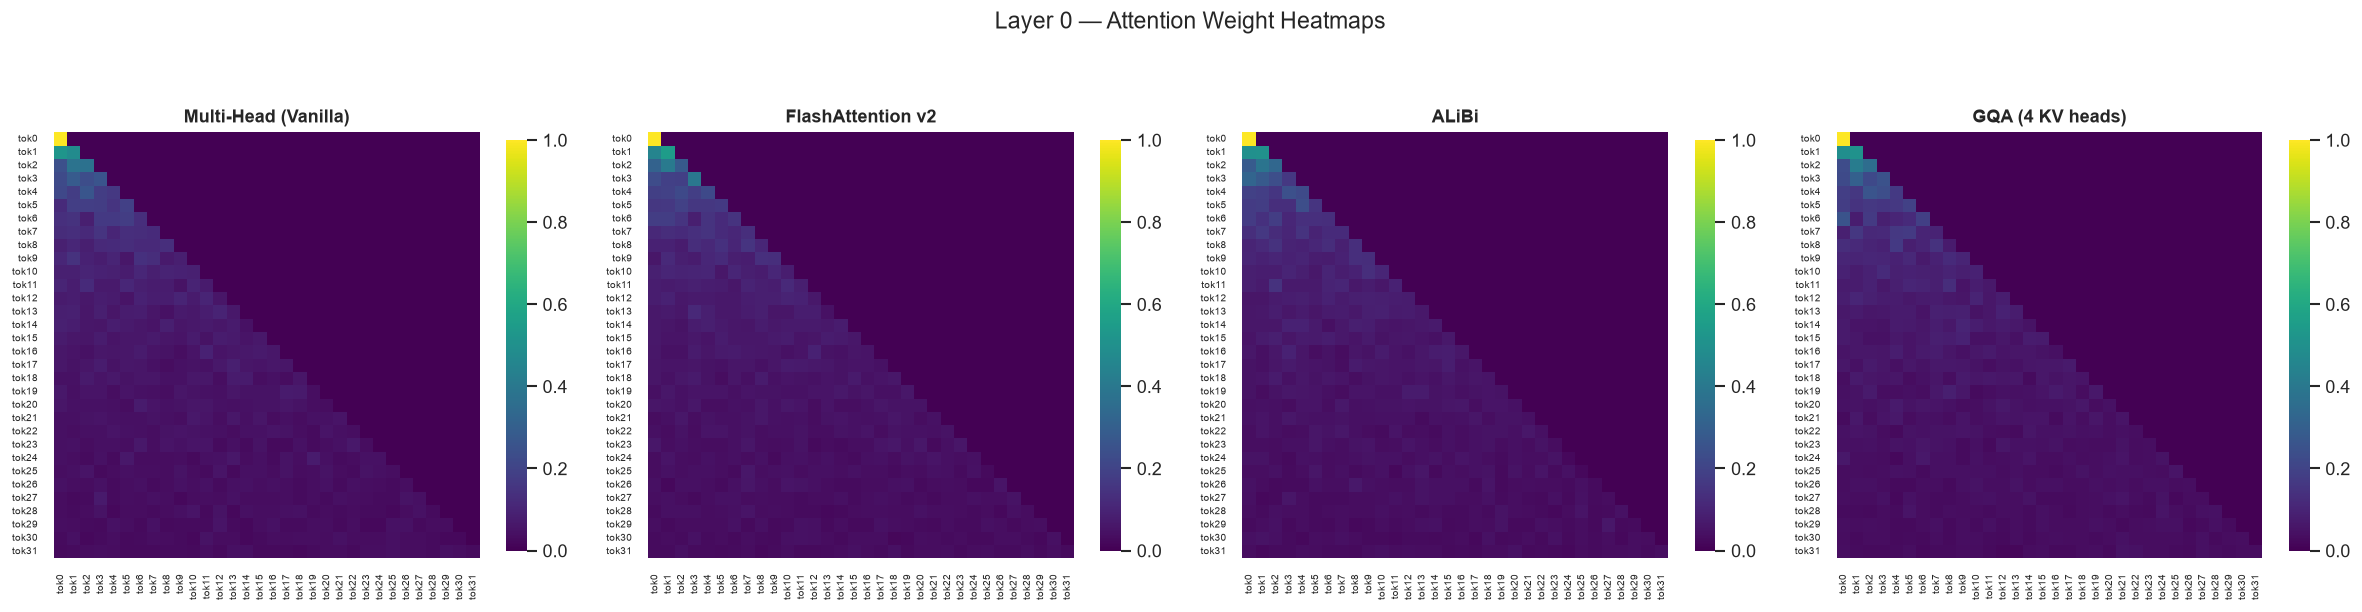

In [6]:
n_variants = len(attention_weights)
fig, axes = plt.subplots(1, n_variants, figsize=(5 * n_variants, 5))
if n_variants == 1:
    axes = [axes]

for ax, (name, attn_dict) in zip(axes, attention_weights.items()):
    if 0 in attn_dict:
        w = attn_dict[0]
        # Handle different tensor shapes
        if w.dim() == 4:  # [B, n_heads, T, T]
            w = w[0, 0].cpu().float().numpy()
        elif w.dim() == 3:  # [n_heads, T, T]
            w = w[0].cpu().float().numpy()
        else:
            w = w.cpu().float().numpy()
        sns.heatmap(w, ax=ax, cmap="viridis", square=True,
                    xticklabels=tokens, yticklabels=tokens,
                    cbar_kws={"shrink": 0.8})
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.tick_params(axis="both", labelsize=6)

fig.suptitle("Layer 0 — Attention Weight Heatmaps", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

### 3.2 — Multi-Head Grid (Single Variant)

For the Flash variant, show all 8 attention heads side by side.

In [7]:
flash_model = list(models.values())[0]  # first model (Multi-Head)
flash_name = list(models.keys())[0]

extractor = AttentionExtractor(flash_model)
try:
    attn_all_heads = extractor.extract(input_ids, layer_idx=0, head_idx=None)
    if 0 in attn_all_heads:
        all_heads = attn_all_heads[0]  # [n_heads, T, T] or [B, n_heads, T, T]
        if all_heads.dim() == 4:
            all_heads = all_heads[0]
        fig = plot_attention_grid(
            all_heads.cpu().float(),
            tokens=tokens,
            title=f"{flash_name} — All Heads (Layer 0)",
            max_heads=8,
        )
        plt.show()
except Exception as e:
    print(f"Multi-head extraction failed: {e}")
finally:
    extractor.remove_hooks()

Multi-head extraction failed: No attention weights were captured. This repo's attention modules return a plain tensor from forward(), not (output, attn_weights), so the forward-hook approach used here can't intercept weights. Use compute_attention_manually() instead.


### 3.3 — Cross-Layer Comparison

Track how attention patterns evolve from early to late layers.

In [8]:
model_for_layers = list(models.values())[1]  # FlashAttention
name_for_layers = list(models.keys())[1]

extractor = AttentionExtractor(model_for_layers)
try:
    all_layers = extractor.extract(input_ids, layer_idx=None, head_idx=0)
    fig = plot_layer_comparison(
        {k: v.cpu().float() for k, v in all_layers.items()},
        tokens=tokens,
        head_idx=0,
        title=f"{name_for_layers} — Attention Across Layers",
        max_layers=6,
    )
    plt.show()
except Exception as e:
    print(f"Layer comparison failed: {e}")
finally:
    extractor.remove_hooks()

Layer comparison failed: No attention weights were captured. This repo's attention modules return a plain tensor from forward(), not (output, attn_weights), so the forward-hook approach used here can't intercept weights. Use compute_attention_manually() instead.


### 3.4 — Head Importance (Entropy)

Entropy measures how "focused" each head is. Lower entropy = more concentrated
attention = higher importance for specific tokens.

In [9]:
model_for_heads = list(models.values())[0]
name_for_heads = list(models.keys())[0]

extractor = AttentionExtractor(model_for_heads)
try:
    head_data = extractor.extract(input_ids, layer_idx=0, head_idx=None)
    if 0 in head_data:
        fig = plot_head_importance(
            head_data[0].cpu().float(),
            tokens=tokens,
            title=f"{name_for_heads} — Head Importance (Layer 0)",
        )
        plt.show()
except Exception as e:
    print(f"Head importance failed: {e}")
finally:
    extractor.remove_hooks()

Head importance failed: No attention weights were captured. This repo's attention modules return a plain tensor from forward(), not (output, attn_weights), so the forward-hook approach used here can't intercept weights. Use compute_attention_manually() instead.


## 4 — Mathematical Differences

Below we discuss the key mathematical distinctions between the four variants.

### 4.1 — Vanilla Multi-Head Attention

Standard scaled dot-product attention:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

where $Q = XW^Q$, $K = XW^K$, $V = XW^V$, and $W^Q, W^K, W^V \in \mathbb{R}^{d_{\text{model}} \times d_k}$.

**Cost:** $O(n^2 \cdot d)$ compute, $O(n^2)$ memory for the attention matrix.

### 4.2 — FlashAttention

FlashAttention computes the **exact same** mathematical result as vanilla attention,
but uses **IO-aware tiling** to avoid materialising the full $n \times n$ attention matrix
in GPU HBM:

1. Tiles $Q$, $K$, $V$ into blocks that fit in SRAM.
2. Computes attention blocks with **online softmax** (rescaling trick).
3. Writes output blocks directly, never storing the full attention matrix.

**Key difference:** Same math, **$O(n)$ memory** instead of $O(n^2)$, 2–4× wall-clock speedup on modern GPUs.

### 4.3 — ALiBi (Attention with Linear Biases)

ALiBi **removes positional embeddings entirely** and instead adds a
deterministic linear bias to the attention scores:

$$\text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} - m \cdot |i - j|\right) V$$

where $m$ is a head-specific slope ($2^{-8/n}, 2^{-16/n}, \ldots$) and $|i-j|$ is the
distance between query position $i$ and key position $j$.

**Key differences from RoPE:**
- No learned parameters for position encoding.
- Linear bias naturally enforces locality (nearby tokens score higher).
- Extrapolates to longer sequences better than sinusoidal/learned encodings.

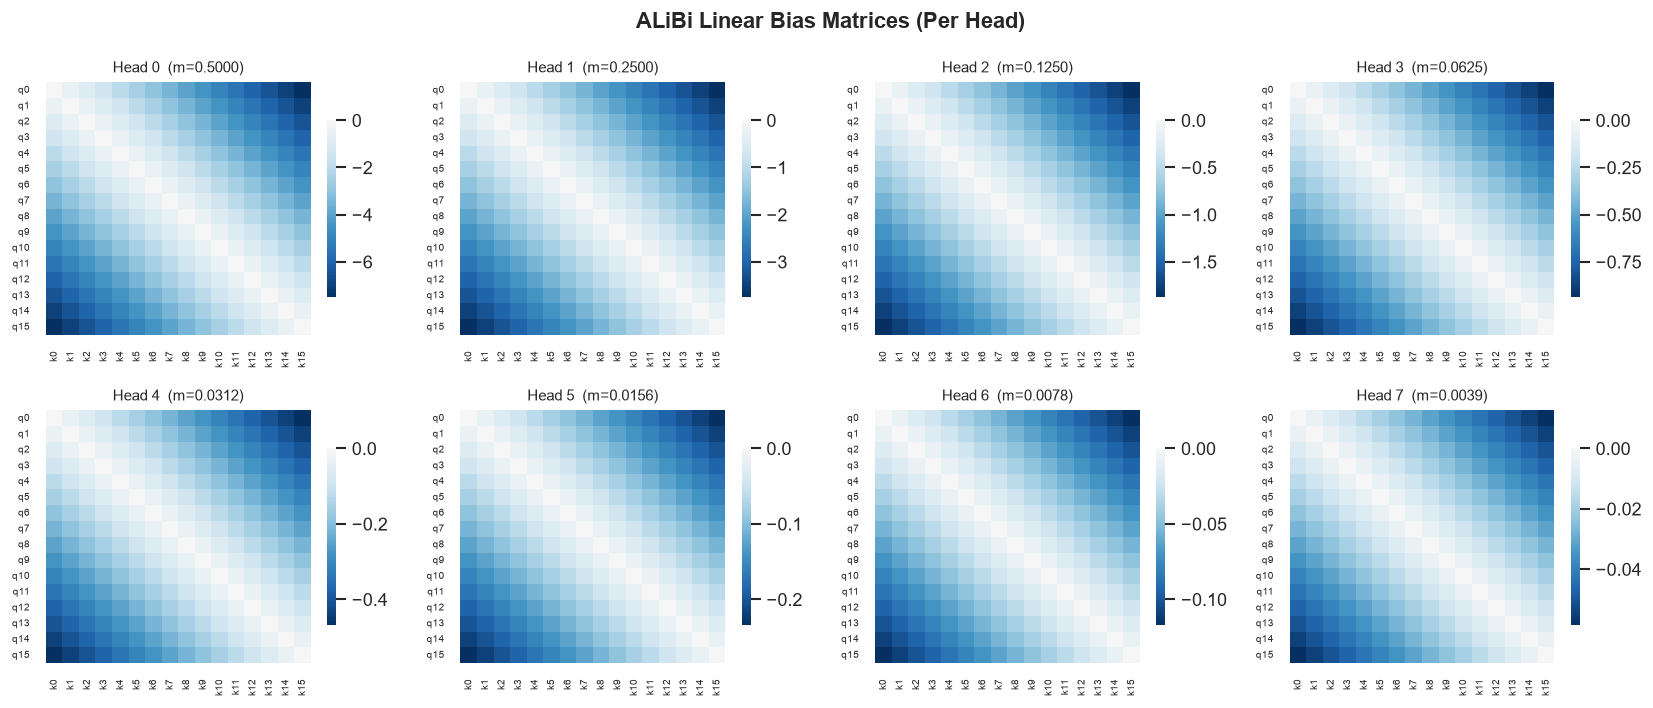

In [11]:
from src.attention.alibi import build_alibi_tensor, get_slope

n_heads_viz = 8
seq_len_viz = 16
alibi_bias = build_alibi_tensor(
    n_heads_viz, seq_len_viz, device="cpu", dtype=torch.float32
)

# Ensure shape is [n_heads, seq_len, seq_len]
if alibi_bias.ndim == 4:
  alibi_bias = alibi_bias.squeeze(0)
elif alibi_bias.ndim == 2:
  alibi_bias = alibi_bias.unsqueeze(0)

# Compute slopes once outside the loop
slopes = get_slope(n_heads_viz)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
  if i < n_heads_viz:
    # alibi_bias[i] is now guaranteed 2D: [seq_len, seq_len]
    matrix_2d = alibi_bias[i].detach().cpu().numpy()

    sns.heatmap(
        matrix_2d,
        ax=ax,
        cmap="RdBu_r",
        center=0,
        xticklabels=[f"k{j}" for j in range(seq_len_viz)],
        yticklabels=[f"q{j}" for j in range(seq_len_viz)],
        cbar_kws={"shrink": 0.7},
    )

    slope_val = (
        slopes[i].item()
        if hasattr(slopes[i], "item")
        else float(slopes[i])
    )
    ax.set_title(f"Head {i}  (m={slope_val:.4f})", fontsize=9)
  ax.tick_params(axis="both", labelsize=6)

fig.suptitle(
    "ALiBi Linear Bias Matrices (Per Head)", fontsize=13, fontweight="bold"
)
fig.tight_layout()
plt.show()

### 4.4 — Grouped-Query Attention (GQA)

GQA shares key and value heads across groups of query heads:

- $n_{\text{q}}$ query heads, $n_{\text{kv}}$ key/value heads.
- Each KV head serves $g = n_{\text{q}} / n_{\text{kv}}$ query heads.
- When $n_{\text{kv}} = 1$, this becomes **Multi-Query Attention (MQA)**.
- When $n_{\text{kv}} = n_{\text{q}}$, this is standard MHA.

**Key difference:** Reduces KV cache size by $n_{\text{q}} / n_{\text{kv}}$, significant memory
savings during autoregressive decoding.

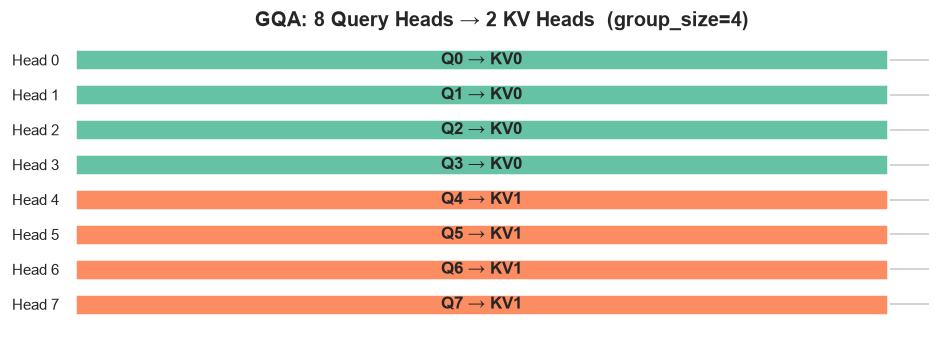

In [12]:
# Illustrate GQA head grouping
n_q, n_kv = 8, 2
group_size = n_q // n_kv

fig, ax = plt.subplots(figsize=(8, 3))
for q_idx in range(n_q):
    kv_idx = q_idx // group_size
    ax.barh(q_idx, 1.0, left=0, height=0.6,
            color=plt.cm.Set2(kv_idx), edgecolor="white", linewidth=1.5)
    ax.text(0.5, q_idx, f"Q{q_idx} → KV{kv_idx}", ha="center", va="center", fontsize=10, fontweight="bold")

ax.set_yticks(range(n_q))
ax.set_yticklabels([f"Head {i}" for i in range(n_q)], fontsize=9)
ax.set_xticks([])
ax.set_title(f"GQA: {n_q} Query Heads → {n_kv} KV Heads  (group_size={group_size})",
             fontsize=12, fontweight="bold")
ax.invert_yaxis()
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

## 5 — Summary Table

In [13]:
import pandas as pd

summary = pd.DataFrame([
    {
        "Variant": "Vanilla MHA",
        "Positional Encoding": "RoPE / Sinusoidal",
        "KV Heads": "n_heads",
        "Memory (attn mat)": "$O(n^2)$",
        "IO Pattern": "Naive",
        "Key Innovation": "Baseline",
    },
    {
        "Variant": "FlashAttention",
        "Positional Encoding": "RoPE / Sinusoidal",
        "KV Heads": "n_heads",
        "Memory (attn mat)": "$O(n)$",
        "IO Pattern": "Tiled SRAM",
        "Key Innovation": "IO-aware online softmax",
    },
    {
        "Variant": "ALiBi",
        "Positional Encoding": "None (linear bias)",
        "KV Heads": "n_heads",
        "Memory (attn mat)": "$O(n^2)$",
        "IO Pattern": "Naive",
        "Key Innovation": "Distance bias, no pos emb",
    },
    {
        "Variant": "GQA",
        "Positional Encoding": "RoPE / Sinusoidal",
        "KV Heads": "n_kv_heads < n_heads",
        "Memory (attn mat)": "$O(n \cdot n_{\text{kv}}/n_{\text{q}})$",
        "IO Pattern": "Naive",
        "Key Innovation": "Shared KV heads",
    },
])

summary

<>:32: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:32: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
C:\Users\aryan\AppData\Local\Temp\ipykernel_15320\1171574423.py:32: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  "Memory (attn mat)": "$O(n \cdot n_{\text{kv}}/n_{\text{q}})$",


,Variant,Positional Encoding,KV Heads,Memory (attn mat),IO Pattern,Key Innovation
0,Vanilla MHA,RoPE / Sinusoidal,n_heads,$O(n^2)$,Naive,Baseline
1,FlashAttention,RoPE / Sinusoidal,n_heads,$O(n)$,Tiled SRAM,IO-aware online softmax
2,ALiBi,None (linear bias),n_heads,$O(n^2)$,Naive,"Distance bias, no pos emb"
3,GQA,RoPE / Sinusoidal,n_kv_heads < n_heads,$O(n \cdot n_{\text{kv}}/n_{\text{q}})$,Naive,Shared KV heads


In [14]:
# Parameter count comparison
param_rows = []
for name, model in models.items():
    n = sum(p.numel() for p in model.parameters())
    param_rows.append({"Variant": name, "Parameters": n, "Params (M)": n / 1e6})

pd.DataFrame(param_rows).set_index("Variant")

,Parameters,Params (M)
Variant,,
Multi-Head (Vanilla),36596736,36.596736
FlashAttention v2,36596736,36.596736
ALiBi,36596736,36.596736
GQA (4 KV heads),36596736,36.596736


## 6 — Cleanup

In [15]:
# Free GPU memory
for m in models.values():
    m.cpu()
del models
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Done.")

Done.
